# Testing ExoMol Linelist Loading and Absorption Calculations

This notebook tests the functionality of `load_ExoMol_linelist()` and `read_korg_linelist()` to ensure linelist coefficients are correctly calculated and compatible with line absorption calculations.

## Section 1: Load Required Libraries and Set Up Paths

In [1]:
using Pkg
Pkg.activate(@__DIR__)

using HDF5
using CSV
using DataFrames
using Korg

# Paths for the TiO ExoMol dataset and legacy Korg linelist
transition_file = "/home/way/KORG_grid/transitions/49Ti-16O__Toto.trans"
states_file = "/home/way/KORG_grid/linelists/exomol/49Ti-16O__Toto.states"
legacy_linelist = "/home/way/KORG_grid/sergeys_linelist.h5"

# Wavelength bounds for ExoMol loading (Å)
lower_wavelength = 6000.0
upper_wavelength = 9000.0

# Test temperature and pressures for absorption
temps = [2000.0, 3000.0]
n_e = [1e12, 1e13]
ξ = 2e5  # 2 km/s in cm/s

# Build a minimal density table for the test
n_densities = Dict(
    Korg.species"H_I" => [1e17, 1e16],
    Korg.species"He_I" => [1e16, 1e15],
    Korg.species"H2" => [1e16, 1e15],
    Korg.species"TiO" => [1e10, 1e10],
)

partition_fns = Dict(
    Korg.species"TiO" => Korg.default_partition_funcs[Korg.species"TiO"]
)

  Activating project at `~/Korg_ExoMol/Korg.jl`


Dict{Korg.Species, Korg.CubicSplines.CubicSpline{Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Float64}} with 1 entry:
  OTi => CubicSpline{Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{…

## Section 2: Test Reading Legacy Korg Linelist

In [2]:
legacy_lines = Korg.read_korg_linelist(legacy_linelist)
println("Legacy linelist lines: ", length(legacy_lines))
println("Sample legacy lines:")
legacy_lines[1:min(end, 5)] |> display

# Inspect broadening parameters for the first few lines
legacy_samples = legacy_lines[1:min(end, 20)]
legacy_broadening = DataFrame(
    wl = [l.wl * 1e8 for l in legacy_samples],
    log_gf = [l.log_gf for l in legacy_samples],
    gamma_rad = [l.gamma_rad for l in legacy_samples],
    gamma_stark = [l.gamma_stark for l in legacy_samples],
    vdW = [l.vdW for l in legacy_samples],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in legacy_samples],
    n_exp = [l.n_exp for l in legacy_samples],
)
legacy_broadening |> display

Legacy linelist lines: 29356559
Sample legacy lines:


5-element Vector{Korg.Line{Float64, Float64, Float64, Float64, Float64, Float64, Float64}}:
 OTi 3000.874669 Å (log gf = -5.69, χ = 1.55 eV)
 OTi 3000.874869 Å (log gf = -4.82, χ = 1.53 eV)
 OTi 3000.875969 Å (log gf = -5.11, χ = 2.77 eV)
 Fe I 3000.877249 Å (log gf = -4.77, χ = 3.3 eV)
 OTi 3000.878169 Å (log gf = -4.24, χ = 1.98 eV)

Row,wl,log_gf,gamma_rad,gamma_stark,vdW,gamma_mol_lorentz,n_exp
,Float64,Float64,Float64,Float64,Tuple…,Missing,Missing
1,3000.87,-5.687,2.73527e7,0.0,"(0.0, -1.0)",missing,missing
2,3000.87,-4.822,2.64241e7,0.0,"(0.0, -1.0)",missing,missing
3,3000.88,-5.105,1.75388e7,0.0,"(0.0, -1.0)",missing,missing
4,3000.88,-4.771,2.04174e7,6.60693e-5,"(4.7863e-8, -1.0)",missing,missing
5,3000.88,-4.237,3.09742e7,0.0,"(0.0, -1.0)",missing,missing
6,3000.88,-16.576,5.88844e6,0.0,"(0.0, -1.0)",missing,missing
7,3000.88,-5.764,2.40991e7,0.0,"(0.0, -1.0)",missing,missing
8,3000.88,-6.589,2.77971e7,0.0,"(0.0, -1.0)",missing,missing
9,3000.88,-6.887,3.01995e7,0.0,"(0.0, -1.0)",missing,missing


## Section 3: Test Loading ExoMol Linelist

In [3]:
tio_lines = Korg.load_ExoMol_linelist(Korg.species"TiO", states_file, transition_file,
                                        lower_wavelength, upper_wavelength;
                                        verbose=true,
                                        line_strength_cutoff=-15,
                                        T_line_strength=3500.0,
                                        path_flag=2
                                        )
println("TiO ExoMol lines: ", length(tio_lines))
println("Sample TiO lines:")
tio_lines[1:min(end, 5)] |> display

# Inspect broadening parameters for TiO lines
sample_tio = tio_lines[1:min(end, 20)]
tio_broadening = DataFrame(
    wl = [l.wl * 1e8 for l in sample_tio],
    log_gf = [l.log_gf for l in sample_tio],
    E_lower = [l.E_lower for l in sample_tio],
    gamma_rad = [l.gamma_rad for l in sample_tio],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in sample_tio],
    n_exp = [l.n_exp for l in sample_tio],
)
tio_broadening |> display

Loading ExoMol linelist from /home/way/KORG_grid/linelists/exomol/49Ti-16O__Toto.states and /home/way/KORG_grid/transitions/49Ti-16O__Toto.trans. This functionality is experimental. Please report any issues.
Assuming the most abundant isotope for all atoms. Use the isotopes keyword argument to specify otherwise.
Removed 52301805 lines with strength below -15 at T = 3500.0 K out of 59322842 total lines (88%).
TiO ExoMol lines: 7021037
Sample TiO lines:


5-element Vector{Korg.Line}:
 OTi 6000.000078 Å (log gf = -2.12, χ = 2.46 eV)
 OTi 6000.000688 Å (log gf = -4.01, χ = 2.15 eV)
 OTi 6000.000763 Å (log gf = -4.01, χ = 2.15 eV)
 OTi 6000.000893 Å (log gf = -2.36, χ = 1.59 eV)
 OTi 6000.00093 Å (log gf = -2.36, χ = 1.59 eV)

Row,wl,log_gf,E_lower,gamma_rad,gamma_mol_lorentz,n_exp
,Float64,Float64,Float64,Float64,Tuple…,Tuple…
1,6000.0,-2.11591,2.4573,1.41881e6,"(0.00854504, 0.00341771)","(0.5, 0.5)"
2,6000.0,-4.01411,2.15334,17936.0,"(0.00815587, 0.00326209)","(0.5, 0.5)"
3,6000.0,-4.01406,2.15334,17938.1,"(0.00815587, 0.00326209)","(0.5, 0.5)"
4,6000.0,-2.36411,1.58542,8.0117e5,"(0.00929429, 0.00371726)","(0.5, 0.5)"
5,6000.0,-2.36411,1.58542,8.0117e5,"(0.00929429, 0.00371726)","(0.5, 0.5)"
6,6000.0,-2.38919,2.26535,7.56221e5,"(0.00824792, 0.00329641)","(0.5, 0.5)"
7,6000.0,-6.8725,2.21441,24.8506,"(0.0557907, 0.0223131)","(0.5, 0.5)"
8,6000.0,-2.87365,1.53972,2.47849e5,"(0.0646827, 0.0258706)","(0.5, 0.5)"
9,6000.0,-3.55998,1.60286,51033.9,"(0.00885392, 0.00354122)","(0.5, 0.5)"


In [4]:
tio_lines_legacy = Korg.load_ExoMol_linelist(Korg.species"TiO", states_file, transition_file,
                                        lower_wavelength, upper_wavelength;
                                        verbose=true,
                                        line_strength_cutoff=-15,
                                        T_line_strength=3500.0,
                                        path_flag=0
                                        )
println("TiO ExoMol lines: ", length(tio_lines_legacy))
println("Sample TiO lines:")
tio_lines_legacy[1:min(end, 5)] |> display

# Inspect broadening parameters for TiO lines
sample_tio_legacy = tio_lines_legacy[1:min(end, 20)]
tio_broadening_legacy = DataFrame(
    wl = [l.wl * 1e8 for l in sample_tio_legacy],
    log_gf = [l.log_gf for l in sample_tio_legacy],
    E_lower = [l.E_lower for l in sample_tio_legacy],
    gamma_rad = [l.gamma_rad for l in sample_tio_legacy],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in sample_tio_legacy],
    n_exp = [l.n_exp for l in sample_tio_legacy],
)
tio_broadening_legacy |> display

Loading ExoMol linelist from /home/way/KORG_grid/linelists/exomol/49Ti-16O__Toto.states and /home/way/KORG_grid/transitions/49Ti-16O__Toto.trans. This functionality is experimental. Please report any issues.
Using default broadening (only radiative) for this species
Assuming the most abundant isotope for all atoms. Use the isotopes keyword argument to specify otherwise.
Removed 52301805 lines with strength below -15 at T = 3500.0 K out of 59322842 total lines (88%).
TiO ExoMol lines: 7021037
Sample TiO lines:


5-element Vector{Korg.Line}:
 OTi 6000.000078 Å (log gf = -2.12, χ = 2.46 eV)
 OTi 6000.000688 Å (log gf = -4.01, χ = 2.15 eV)
 OTi 6000.000763 Å (log gf = -4.01, χ = 2.15 eV)
 OTi 6000.000893 Å (log gf = -2.36, χ = 1.59 eV)
 OTi 6000.00093 Å (log gf = -2.36, χ = 1.59 eV)

Row,wl,log_gf,E_lower,gamma_rad,gamma_mol_lorentz,n_exp
,Float64,Float64,Float64,Float64,Missing,Missing
1,6000.0,-2.11591,2.4573,1.41881e6,missing,missing
2,6000.0,-4.01411,2.15334,17936.0,missing,missing
3,6000.0,-4.01406,2.15334,17938.1,missing,missing
4,6000.0,-2.36411,1.58542,8.0117e5,missing,missing
5,6000.0,-2.36411,1.58542,8.0117e5,missing,missing
6,6000.0,-2.38919,2.26535,7.56221e5,missing,missing
7,6000.0,-6.8725,2.21441,24.8506,missing,missing
8,6000.0,-2.87365,1.53972,2.47849e5,missing,missing
9,6000.0,-3.55998,1.60286,51033.9,missing,missing


## Section 4: Compare Line Properties Between Formats

In [5]:
function summarize_lines(lines, n=10)
    DataFrame(
        wl = [l.wl * 1e8 for l in lines[1:min(end, n)]],
        log_gf = [l.log_gf for l in lines[1:min(end, n)]],
        E_lower = [l.E_lower for l in lines[1:min(end, n)]],
        gamma_rad = [l.gamma_rad for l in lines[1:min(end, n)]],
        gamma_stark = [l.gamma_stark for l in lines[1:min(end, n)]],
        vdW = [l.vdW for l in lines[1:min(end, n)]],
        gamma_mol_lorentz = [l.gamma_mol_lorentz for l in lines[1:min(end, n)]],
        n_exp = [l.n_exp for l in lines[1:min(end, n)]],
    )
end

println("Legacy linelist summary")
summarize_lines(legacy_lines, 10) |> display

println("TiO ExoMol linelist summary")
summarize_lines(tio_lines, 10) |> display

Row,wl,log_gf,E_lower,gamma_rad,gamma_stark,vdW,gamma_mol_lorentz,n_exp
,Float64,Float64,Float64,Float64,Float64,Tuple…,Missing,Missing
1,3000.87,-5.687,1.5517,2.73527e7,0.0,"(0.0, -1.0)",missing,missing
2,3000.87,-4.822,1.5289,2.64241e7,0.0,"(0.0, -1.0)",missing,missing
3,3000.88,-5.105,2.7696,1.75388e7,0.0,"(0.0, -1.0)",missing,missing
4,3000.88,-4.771,3.3009,2.04174e7,6.60693e-5,"(4.7863e-8, -1.0)",missing,missing
5,3000.88,-4.237,1.9763,3.09742e7,0.0,"(0.0, -1.0)",missing,missing
6,3000.88,-16.576,0.091,5.88844e6,0.0,"(0.0, -1.0)",missing,missing
7,3000.88,-5.764,2.5773,2.40991e7,0.0,"(0.0, -1.0)",missing,missing
8,3000.88,-6.589,1.9563,2.77971e7,0.0,"(0.0, -1.0)",missing,missing
9,3000.88,-6.887,1.7548,3.01995e7,0.0,"(0.0, -1.0)",missing,missing


Legacy linelist summary
TiO ExoMol linelist summary


Row,wl,log_gf,E_lower,gamma_rad,gamma_stark,vdW,gamma_mol_lorentz,n_exp
,Float64,Float64,Float64,Float64,Missing,Missing,Tuple…,Tuple…
1,6000.0,-2.11591,2.4573,1.41881e6,missing,missing,"(0.00854504, 0.00341771)","(0.5, 0.5)"
2,6000.0,-4.01411,2.15334,17936.0,missing,missing,"(0.00815587, 0.00326209)","(0.5, 0.5)"
3,6000.0,-4.01406,2.15334,17938.1,missing,missing,"(0.00815587, 0.00326209)","(0.5, 0.5)"
4,6000.0,-2.36411,1.58542,8.0117e5,missing,missing,"(0.00929429, 0.00371726)","(0.5, 0.5)"
5,6000.0,-2.36411,1.58542,8.0117e5,missing,missing,"(0.00929429, 0.00371726)","(0.5, 0.5)"
6,6000.0,-2.38919,2.26535,7.56221e5,missing,missing,"(0.00824792, 0.00329641)","(0.5, 0.5)"
7,6000.0,-6.8725,2.21441,24.8506,missing,missing,"(0.0557907, 0.0223131)","(0.5, 0.5)"
8,6000.0,-2.87365,1.53972,2.47849e5,missing,missing,"(0.0646827, 0.0258706)","(0.5, 0.5)"
9,6000.0,-3.55998,1.60286,51033.9,missing,missing,"(0.00885392, 0.00354122)","(0.5, 0.5)"


## Section 5: Validate Broadening Coefficients

In [6]:
tio_mode2_count = count(map(!, ismissing.(getfield.(tio_lines, :gamma_mol_lorentz))))
println("TiO ExoMol lines with Mode 2 broadening: $tio_mode2_count / $(length(tio_lines))")

mode2_samples = filter(l -> !ismissing(l.gamma_mol_lorentz), tio_lines)
mode2_summary = DataFrame(
    wl = [l.wl * 1e8 for l in mode2_samples[1:min(end, 20)]],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in mode2_samples[1:min(end, 20)]],
    n_exp = [l.n_exp for l in mode2_samples[1:min(end, 20)]],
)
mode2_summary |> display

legacy_mode2_count = count(map(!, ismissing.(getfield.(legacy_lines, :gamma_mol_lorentz))))
println("Legacy lines with Mode 2 broadening: $legacy_mode2_count / $(length(legacy_lines))")

TiO ExoMol lines with Mode 2 broadening: 7021037 / 7021037
Legacy lines with Mode 2 broadening: 0 / 29356559


Row,wl,gamma_mol_lorentz,n_exp
,Float64,Tuple…,Tuple…
1,6000.0,"(0.00854504, 0.00341771)","(0.5, 0.5)"
2,6000.0,"(0.00815587, 0.00326209)","(0.5, 0.5)"
3,6000.0,"(0.00815587, 0.00326209)","(0.5, 0.5)"
4,6000.0,"(0.00929429, 0.00371726)","(0.5, 0.5)"
5,6000.0,"(0.00929429, 0.00371726)","(0.5, 0.5)"
6,6000.0,"(0.00824792, 0.00329641)","(0.5, 0.5)"
7,6000.0,"(0.0557907, 0.0223131)","(0.5, 0.5)"
8,6000.0,"(0.0646827, 0.0258706)","(0.5, 0.5)"
9,6000.0,"(0.00885392, 0.00354122)","(0.5, 0.5)"


## Section 6: Test Line Absorption Calculations

In [7]:
# using Korg: Wavelengths

# λs = Wavelengths((lower_wavelength:0.1:upper_wavelength) * 1e-8)
# α_exomol = zeros(Float64, length(temps), length(λs))
# α_legacy = zeros(Float64, length(temps), length(λs))

# α_cntm = x -> 1e-20  # small flat continuum for window estimation

# #println("Computed absorption for TiO ExoMol lines")

# Korg.line_absorption!(α_exomol, 
#                       tio_lines, 
#                       λs, 
#                       temps, 
#                       n_e, 
#                       n_densities, 
#                       partition_fns, 
#                       ξ, 
#                       α_cntm)
# # # for legacy lines, assume same density/partition functions for any species present
# # legacy_partition_fns = Dict(
# #     Korg.species"TiO" => Korg.default_partition_funcs[Korg.species"TiO"]
# # )
# # Korg.line_absorption!(α_legacy, legacy_lines, λs, temps, n_e, n_densities, legacy_partition_fns, ξ, α_cntm)
# # println("Computed absorption for legacy Korg linelist lines")

# # DataFrame(
# #     λ = λs .* 1e8,
# #     α_exomol_T1 = α_exomol[1, :],
# #     α_exomol_T2 = α_exomol[2, :],
# #     α_legacy_T1 = α_legacy[1, :],
# #     α_legacy_T2 = α_legacy[2, :]
# # )[1:10, :] |> display



# Try synthesiszing spectra

In [8]:
foo = [line for line in legacy_lines if line.species != Korg.Species("TiO")]

901785-element Vector{Korg.Line{Float64, Float64, Float64, Float64, Float64, Float64, Float64}}:
 Fe I 3000.877249 Å (log gf = -4.77, χ = 3.3 eV)
 C2 3000.87827 Å (log gf = -16.58, χ = 0.09 eV)
 CN 3000.894624 Å (log gf = -8.36, χ = 0.51 eV)
 Fe I 3000.894804 Å (log gf = -8.67, χ = 3.33 eV)
 Fe I 3000.895074 Å (log gf = -7.63, χ = 3.33 eV)
 CN 3000.897504 Å (log gf = -8.24, χ = 0.51 eV)
 Mn II 3000.902376 Å (log gf = -8.3, χ = 9.41 eV)
 HN 3000.905716 Å (log gf = -5.56, χ = 0.14 eV)
 CN 3000.912008 Å (log gf = -6.46, χ = 1.13 eV)
 Cr II 3000.92191 Å (log gf = -0.58, χ = 8.23 eV)
 ⋮
 Ni II 10002.660705 Å (log gf = -2.47, χ = 14.99 eV)
 C2 10002.665166 Å (log gf = -8.18, χ = 2.26 eV)
 Fe I 10002.665706 Å (log gf = -1.42, χ = 5.5 eV)
 Mn III 10002.670718 Å (log gf = -3.52, χ = 25.89 eV)
 Fe II 10002.674719 Å (log gf = -3.69, χ = 11.75 eV)
 CN 10002.692724 Å (log gf = -5.16, χ = 0.88 eV)
 CN 10002.707738 Å (log gf = -3.5, χ = 0.77 eV)
 Ce II 10002.723742 Å (log gf = -2.26, χ = 0.67 eV)
 CO

In [9]:
# Check what types you actually have
@show typeof(foo)
@show typeof(tio_lines_legacy)

# Force a concrete element type
linelist = vcat(foo, tio_lines_legacy)
@assert eltype(linelist) != Any "linelist is Vector{Any} — element types don't match"

typeof(foo) = Vector{Korg.Line{Float64, Float64, Float64, Float64, Float64, Float64, Float64}}
typeof(tio_lines_legacy) = Vector{Korg.Line}


┌ Warning: Linelist isn't sorted. Sorting it, which may cause a significant delay.
└ @ Korg /home/way/Korg_ExoMol/Korg.jl/src/synthesize.jl:192


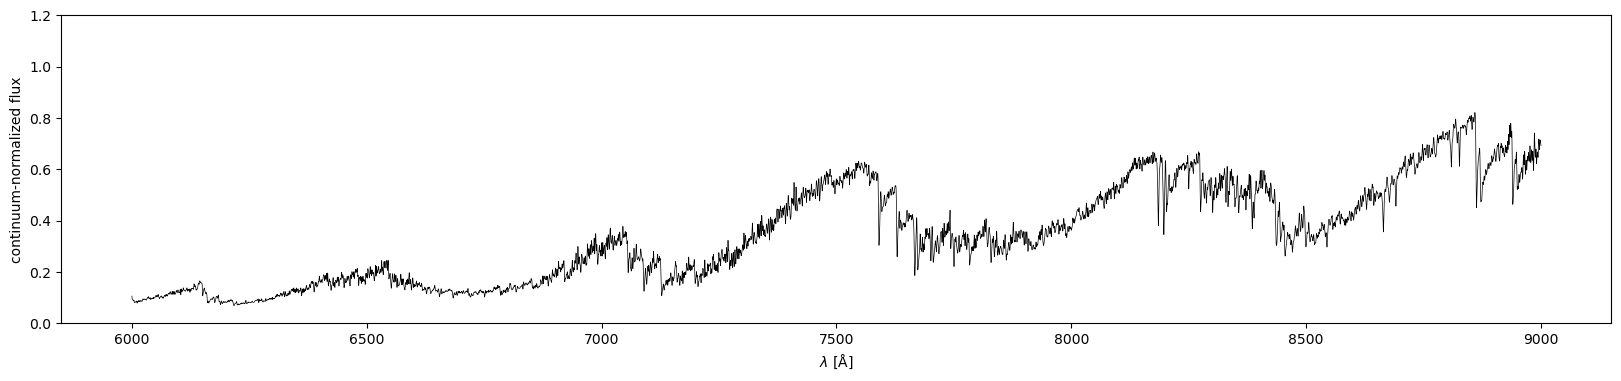

In [10]:
using PythonPlot
temp_linelist = vcat(foo, tio_lines)
wls, flux, continuum = synth(
    Teff=3500, # effective temperature of 5000 Kelvin
    logg=5.0, # surface gravity of 10^(4.32) cm/s²
    M_H=0.5,  # metallicity, [M/H]. Overridden for individual elements by alpha_H and individual abundances
    #C=0.0,    # The Carbon abundance, [C/H].  Works for anything from He to U.
    linelist=temp_linelist,
    wavelengths=(lower_wavelength, upper_wavelength),
    R=5_000,
)

# plot
figure(figsize=(20, 4))
plot(wls, flux, "k-", lw=0.5)
ylim(0,1.2)
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")
display(gcf())

┌ Warning: Linelist isn't sorted. Sorting it, which may cause a significant delay.
└ @ Korg /home/way/Korg_ExoMol/Korg.jl/src/synthesize.jl:192


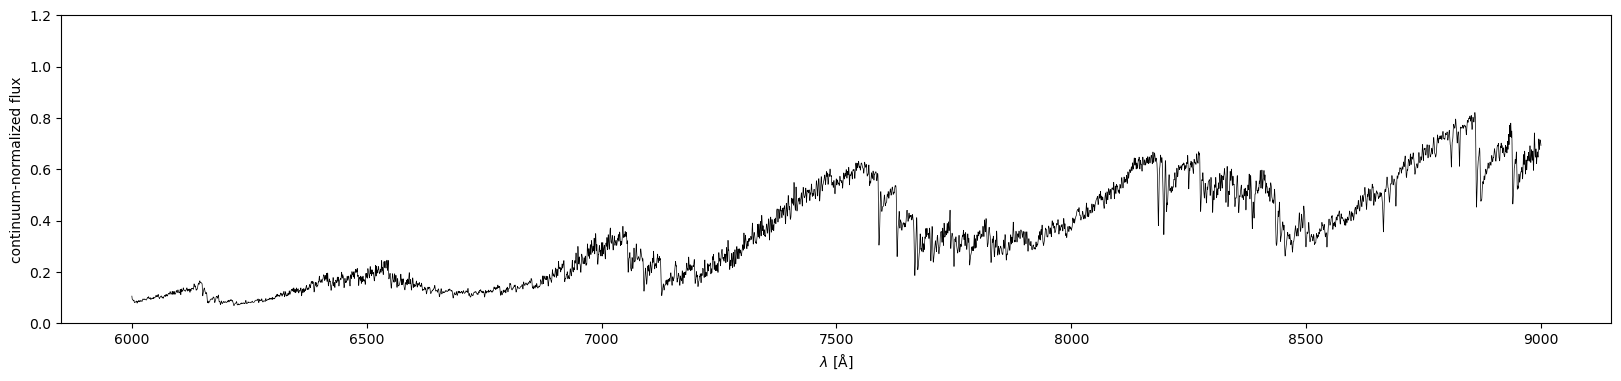

In [11]:
using PythonPlot

wls_tio_legacy, flux_tio_legacy, continuum_tio_legacy = synth(
    Teff=3500, # effective temperature of 5000 Kelvin
    logg=5.0, # surface gravity of 10^(4.32) cm/s²
    M_H=0.5,  # metallicity, [M/H]. Overridden for individual elements by alpha_H and individual abundances
    #C=0.0,    # The Carbon abundance, [C/H].  Works for anything from He to U.
    linelist=vcat(foo, tio_lines_legacy),
    wavelengths=(lower_wavelength, upper_wavelength),
    R=5_000,
)

# plot
figure(figsize=(20, 4))
plot(wls_tio_legacy, flux_tio_legacy, "k-", lw=0.5)
ylim(0,1.2)
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")
display(gcf())

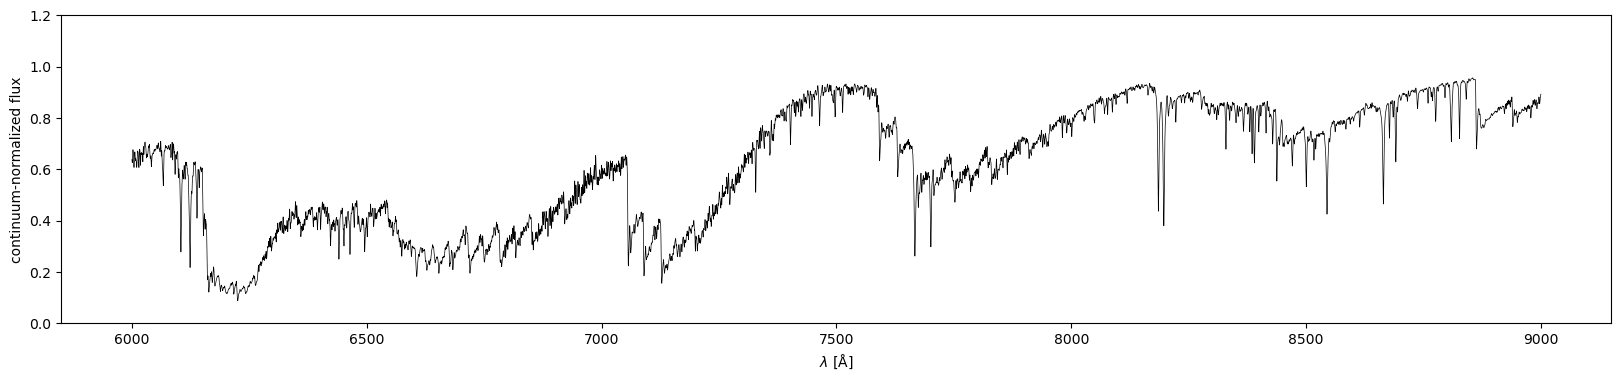

In [12]:
wls_legacy, flux_legacy, continuum_legacy = synth(
    Teff=3500, # effective temperature of 5000 Kelvin
    logg=5.0, # surface gravity of 10^(4.32) cm/s²
    M_H=0.5,  # metallicity, [M/H]. Overridden for individual elements by alpha_H and individual abundances
    #C=0.0,    # The Carbon abundance, [C/H].  Works for anything from He to U.
    linelist=legacy_lines,
    wavelengths=(lower_wavelength, upper_wavelength),
    R=5_000
)

# plot
figure(figsize=(20, 4))
plot(wls_legacy, flux_legacy, "k-", lw=0.5)
ylim(0,1.2)
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")
display(gcf())

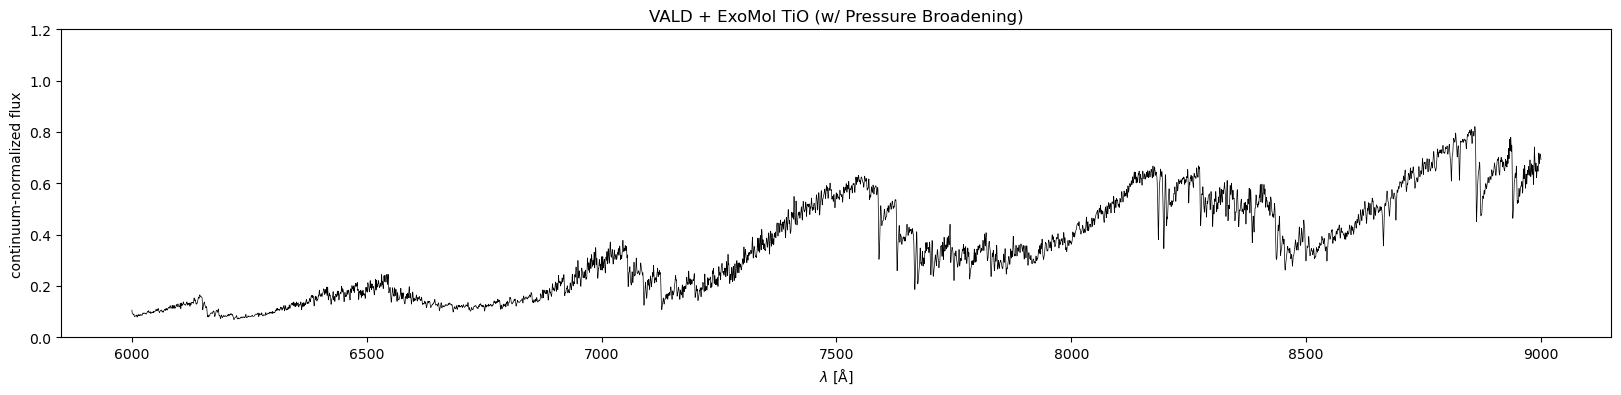

In [13]:
# plot
figure(figsize=(20, 4))
plot(wls, flux, "k-", lw=0.5)
ylim(0,1.2)
title("VALD + ExoMol TiO (w/ Pressure Broadening)")
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")
display(gcf())

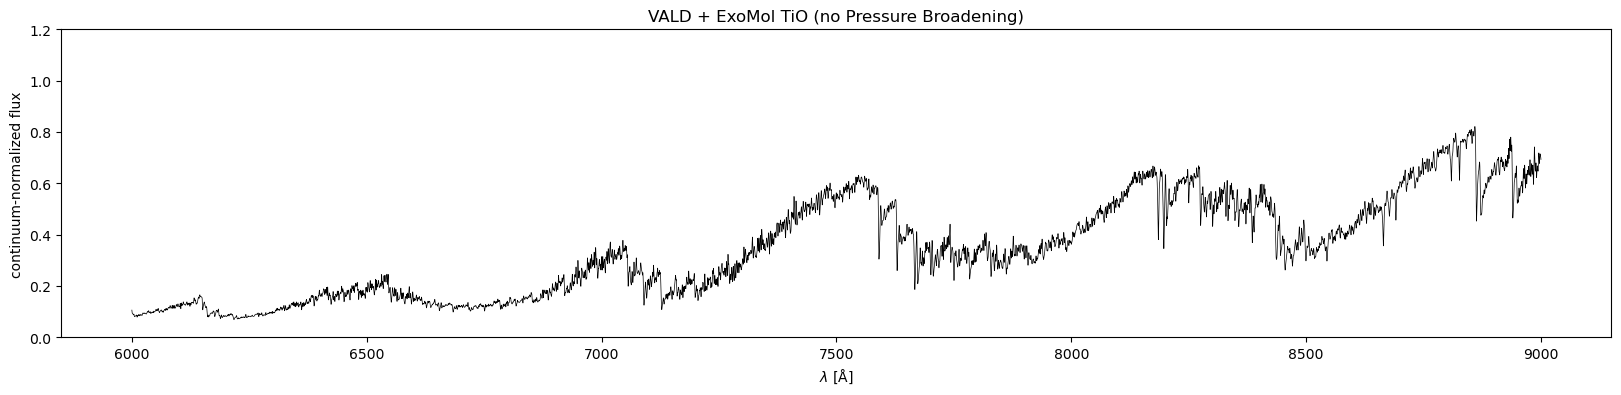

In [14]:
# plot
figure(figsize=(20, 4))
plot(wls_tio_legacy, flux_tio_legacy, "k-", lw=0.5)
ylim(0,1.2)
title("VALD + ExoMol TiO (no Pressure Broadening)")
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")
display(gcf())

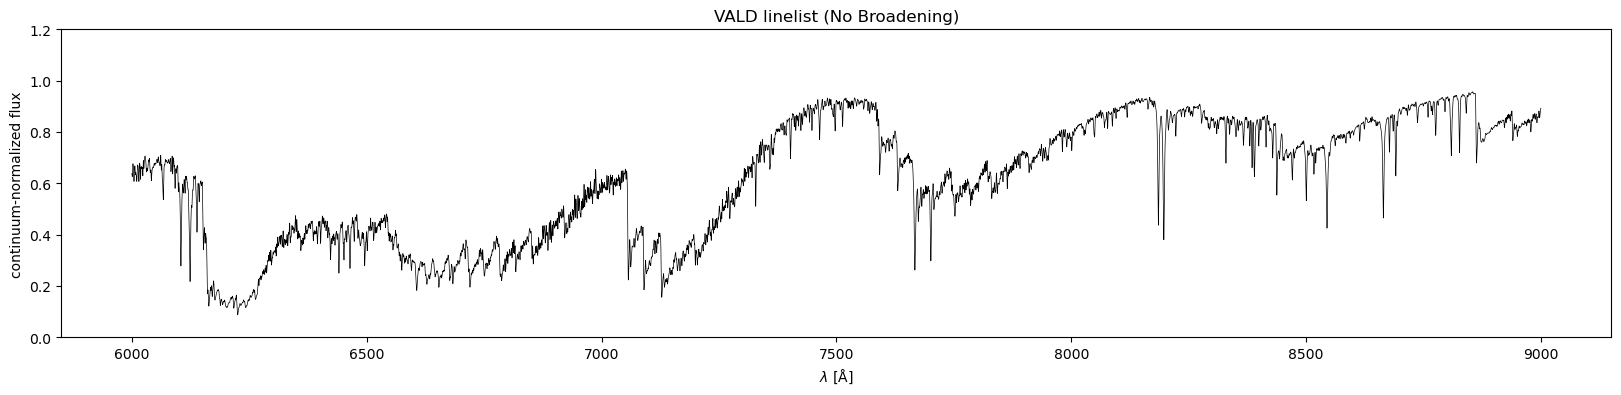

In [15]:
figure(figsize=(20, 4))
plot(wls_legacy, flux_legacy, "k-", lw=0.5)
ylim(0,1.2)
title("VALD linelist (No Broadening)")
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")
display(gcf())

In [16]:
using CSV, DataFrames

In [17]:
df = DataFrame(wvl=wls, flux=flux, continuum=continuum)
CSV.write("../exomol_w_breadening_tio_spectrum.csv", df)

"../exomol_w_breadening_tio_spectrum.csv"

In [18]:
df = DataFrame(wvl=wls_tio_legacy, flux=flux_tio_legacy, continuum=continuum_tio_legacy)
CSV.write("../exomol_w_o_breadening_tio_spectrum.csv", df)

"../exomol_w_o_breadening_tio_spectrum.csv"

In [19]:
df = DataFrame(wvl=wls_legacy, flux=flux_legacy, continuum=continuum_legacy)
CSV.write("../vald_w_o_broadening_tio_spectrum.csv", df)

"../vald_w_o_broadening_tio_spectrum.csv"

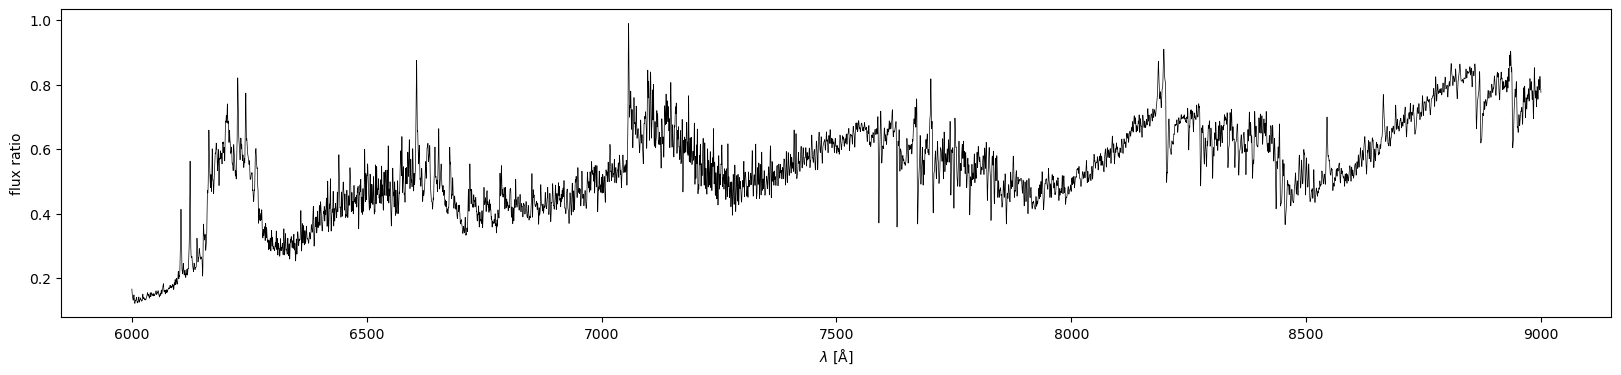

In [11]:
figure(figsize=(20, 4))
plot(wls_legacy, flux./flux_legacy, "k-", lw=0.5)
xlabel(L"$\lambda$ [Å]")
ylabel("flux ratio")
display(gcf())